# <u>Bayesian linear Regression</u>

### Prerequisites:
* <a href="../4.Ridge,Lasso%20and%20Elastic%20Net%20Regression/Ridge,Lasso%20and%20Elastic%20Net%20Regression.ipynb">Check out the notebook on Ridge,Lasso and Elastic Net Regression</a>

## Topics

* [0. Motivation](#motivation)
    
* [1. Derivation](#derive)
    * [1.1 Prior and Likelihood](#prior)
    * [1.2 Posterior](#posterior)
    * [1.3 Special case Posterior](#post)

* [2. Prior predictive distribution](#prior_dist)
* [3. Posterior predictive distribution](#posterior_dist)
* [4. Bayesian linear Regression with libraries](#library)


In [2]:
import numpy as np # for random numbers and Linear algebra
import matplotlib.pyplot as plt # for plotting
from sklearn.linear_model import BayesianRidge # for Bayesian linear Regression (less flexible with fixed model assumption)
import pymc as pm # for Bayesian linear Regression (more math like and more flexible)
import bambi as bmb # for Bayesian linear Regression (more like lm() in R)
from scipy.stats import norm, multivariate_normal # for normal distribution pdf and multivariate normal distribution pdf
print("Setup complete")

Setup complete


<a class="anchor" id="ridge"></a>
# 0. Motivation

**Instead of finding one best set of parameters $\theta$ via OLS, Ridge or Lasso Bayesian Linear Regression tries to model uncertainty about the parameters themselves by deriving a probability distribution over $\theta$.**

That means instead of finding out that <u>the parameter vector is $\hat{\theta}=(2.3,0.4)$</u> we find out that <u>the parameter vector is probably around $\hat{\theta}=(2.3,0.4)$ with this uncertainty</u> which means the parameter vector $\theta$ is now random, not fixed.

This is crucial when:
- data is small
- noise is high
- decisions depend on confidence (not just prediction)

### Connection to Ridge and Lasso ?
* Ridge regression $\Rightarrow$ assumes coefficients have a Gaussian prior
* Lasso regression $\Rightarrow$ assumes coefficients have a Laplace prior

So:

* Ridge/Lasso $\Rightarrow$ MAP estimates (maximum a posteriori)
* Bayesian linear regression $\Rightarrow$ full posterior, not just the maximum

&#128073; Motivation: don’t throw away the rest of the distribution


<a class="anchor" id="derive"></a>
# 1. Derivation

<a class="anchor" id="prior"></a>
## 1.1 Prior and Likelihood

<div style="display:flex; gap:20px;">

<!-- Prior -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
<!--text-align: center;-->
">

<h5 style="text-align:center;"><b>Prior</b></h5>

$$
\theta \sim \mathcal{N}(\theta_0,V_0)
$$

$$
\theta_0 \in \mathbb{R}^m, V_0 \in \mathbb{R}^{m \times m}
$$

$$
\begin{align*}
p(\theta) 
&= \mathcal{N}(\theta \mid \theta_0,V_0) \\
&= \frac{1}{(2\pi)^{m/2} \det(V_0)^{1/2}} \exp \left(-\frac{1}{2} (\theta-\theta_0)^\top V_0^{-1} (\theta-\theta_0)\right)
\end{align*}
$$

- Prior belief about $\theta$ before seeing data
- Example: Setting prior $\mathcal{N}(\theta_0=\begin{pmatrix} 1.0 \\ 6.5\end{pmatrix},V_0 = \begin{pmatrix} 2.1 & 5.6 \\ 5.6 & 7.4 \end{pmatrix})$ means we believe $\theta_{00}=1.0$ tends to be small with low variability $(\mathrm{Var}(\theta_{00})=2.1)$ whereas $\theta_{01}=6.5$ tends to be large with large variability $(\mathrm{Var}(\theta_{01})=7.4)$. We also believe that as $\theta_{00}$ increases  $\theta_{01}$ also increases and is likely larger than $\theta_{00}$ $(\mathrm{Cov}(\theta_{00},\theta_{01})=5.6)$. 

<p align="center">
<img src="prior.png" width="400"/>
</p>

</div>

<!-- Likelihood -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
<!--text-align: center;-->
">

<h5 style="text-align:center;"><b>Likelihood</b></h5>

$$
y \mid X, \theta \sim \mathcal{N}(X\theta,\Sigma) \hspace{0.5 mm} \text{ since } \varepsilon \sim \mathcal{N}(0,\Sigma) \hspace{0.5 mm} \text{ and } y=X\theta + \varepsilon \\
$$

$$
y \in \mathbb{R}^n, X \in \mathbb{R}^{n \times m}, \theta \in \mathbb{R}^m, X\theta \in \mathbb{R}^n, \Sigma \in \mathbb{R}^{n \times n},
\varepsilon \in \mathbb{R}^n
$$


$$
\begin{align*}
p(y \mid X,\theta) 
&= \mathcal{N}(y\mid X\theta,\Sigma) \\
&= \frac{1}{(2\pi)^{n/2} \det(\Sigma)^{1/2}} \exp \left(-\frac{1}{2} (y-X\theta)^\top \Sigma^{-1} (y-X\theta)\right)
\end{align*}
$$

</div>
</div>

<a class="anchor" id="posterior"></a>
## 1.2 Posterior

$$
\underbrace{p(\theta \mid X,y)}_{\text{Posterior}} = \frac{p(y \mid X,\theta)p(\theta)}{p(y)}, \quad p(y) \text{ is called evidence}
$$

Using Bayes' rule: $$p(\theta \mid X,y) \propto p(y \mid X,\theta) p(\theta)$$

Becasue:
- Likelihood is Gaussian 
- Prior is Gaussian

$\Rightarrow$ Posterior is also Gaussian 

$$
\begin{align*}
p(\theta \mid X,y) 
&= \mathcal{N}(\theta \mid \theta_n, V_n) \\
&= \frac{1}{(2\pi)^{m/2} \det(V_n)^{1/2}} \exp \left(-\frac{1}{2} (\theta-\theta_n)^\top V_n^{-1} (\theta-\theta_n)\right) \\
\text{Posterior covariance: }& V_n = (X^\top \Sigma^{-1} X + V_0^{-1})^{-1} \\
\text{Posterior mean: }& \theta_n = V_n(V_0^{-1}\theta_0 + X^\top \Sigma^{-1}y) \\
\end{align*}
$$


<a class="anchor" id="post"></a>
## 1.3 Special case Posterior

For
- $\Sigma = \sigma^2 \mathrm{I}$ (data noise)
- $V_0 = \tau^2 \mathrm{I}$ (prior uncertainty)
- $\theta_0 = 0$ (prior mean)

$$
\begin{align*}
\text{Posterior covariance: } V_n &= (X^\top \Sigma^{-1} X + V_0^{-1})^{-1} \\
&= (X^\top (\sigma^2 \mathrm{I})^{-1} X + (\tau^2 \mathrm{I})^{-1})^{-1} \\  
&= \left(\frac{1}{\sigma^2} X^\top  X + \frac{1}{\tau^2} \mathrm{I}\right)^{-1} \\  
&= \left(\frac{1}{\sigma^2} \left[X^\top  X + \frac{\sigma^2}{\tau^2} \mathrm{I}\right]\right)^{-1}  \hspace{1 mm} \mid \hspace{1 mm} \lambda := \frac{\sigma^2}{\tau^2} \\ 
&= \underbrace{\sigma^2 \left[X^\top  X + \lambda \mathrm{I}\right]^{-1}}_{\text{posterior uncertainty about } \theta} \neq \mathbb{Var}(\hat{\theta}_\text{Ridge})  \\ 
\\

\text{Posterior mean: } \theta_n &= V_n(V_0^{-1}\theta_0 + X^\top \Sigma^{-1}y) \\
&= \sigma^2 \left(X^\top  X + \lambda \mathrm{I}\right)^{-1}((\tau^2 \mathrm{I})^{-1} 0 + X^\top (\sigma^2 \mathrm{I})^{-1}y) \\
&= \sigma^2 \left(X^\top  X + \lambda \mathrm{I}\right)^{-1}\frac{1}{\sigma^2}X^\top y \\
&=  \left(X^\top  X + \lambda \mathrm{I}\right)^{-1} X^\top y = \hat{\theta}_{\text{Ridge}} \\
\end{align*}
$$

True weights: [ 3.  -2.  -2.8]
Posterior mean: [ 3.014704   -1.24454216 -3.17969043]
Shape of theta_sampels: (5000, 3)


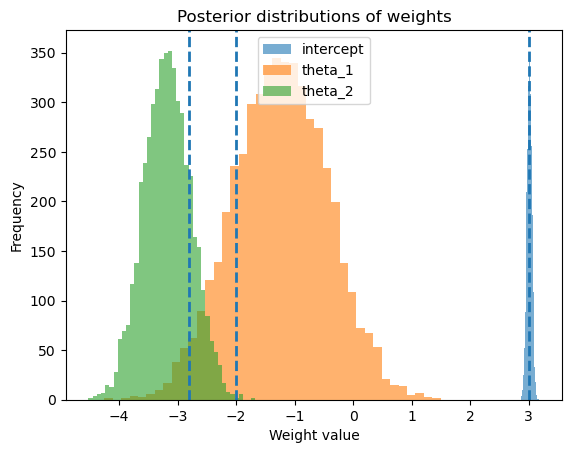

In [3]:
# 1. Generate data
np.random.seed(1926)

n = 50

# Highly correlated predictors
x1 = np.random.randn(n)
x2 = 2 * x1 + 0.05 * np.random.randn(n) # x2 = 2*x1 + small_noise

# Design matrix with intercept
X = np.column_stack([np.ones(n), x1, x2])

# True weights
theta_true = np.array([3, -2, -2.8])

# Noise variance and prior variance
sigma2 = 0.3**2
tau2 = 1.0

# Generate targets
y = X @ theta_true + np.sqrt(sigma2) * np.random.randn(n)


# 2. Bayesian linear regression (closed form)
# Likelihood covariance
Sigma = sigma2 * np.eye(n)

# Prior
V0 = tau2 * np.eye(X.shape[1])
# for theta_0 = np.array([4, 0, 0]) -> intercept pulled toward 4 and slopes pulled toward 0 and 0 but strenght of pulling depends on tau 
# (i.e. tau = 1 means moderate pulling)
theta_0 = np.array([4, 0, 0])

# Posterior covariance
Vn = np.linalg.inv(X.T @ np.linalg.inv(Sigma) @ X + np.linalg.inv(V0)) 

# Posterior mean (equals ridge solution)
theta_n = Vn @ (np.linalg.inv(V0) @ theta_0 + X.T @ np.linalg.inv(Sigma) @ y)

print("True weights:", theta_true)
print("Posterior mean:", theta_n)



# 3. Sample from the posterior over weights
num_samples = 5000
theta_samples = np.random.multivariate_normal(mean=theta_n, cov=Vn, size=num_samples)
# np.random.multivariate_normal(mean=[3], cov=[[4]],size=3) is equal to np.random.normal(loc=3,scale=4,size=3)
print("Shape of theta_sampels:",theta_samples.shape)


# 4. Plot posterior distributions of weights
labels = ["intercept", "theta_1", "theta_2"]

plt.figure()
for i in range(theta_samples.shape[1]):
    plt.hist(theta_samples[:, i], bins=40, alpha=0.6, label=labels[i])

# True weights 
for val in theta_true:
    plt.axvline(val, linestyle="--", linewidth=2)

plt.legend()
plt.title("Posterior distributions of weights")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.show()

<a class="anchor" id="prior_dist"></a>
## 2. Prior predictive distribution

**The prior predictive distribution (also called the marginal likelihood of new data under the prior) is the distribution of data points before any data is observed and it is based only on our prior beliefs about the data generating parameters.**

$$
\begin{align*}
p(y) &= \int_{\theta \in \Theta} p(y,\theta)d\theta \hspace{1 mm} \text{ marginalizes out the unknown parameter }\theta \\
p(y \mid \theta) = \frac{p(y,\theta)}{p(\theta)} &\Leftrightarrow p(y \mid \theta)p(\theta) = p(y,\theta) \\
p(y) &= \int_{\theta \in \Theta} p(y \mid \theta)p(\theta)d\theta \\ &= \int_{\theta \in \Theta} \underbrace{p(y \mid X, \theta)}_{\text{Likelihood}} \underbrace{p(\theta)}_{\text{Prior}}d\theta \\
&= \int_{\theta \in \mathbb{R}^m} \mathcal{N}(y\mid X\theta,\Sigma) \mathcal{N}(\theta \mid \theta_0,V_0) d\theta \hspace{1mm} \mid \hspace{1mm} X \in \mathbb{R}^{n \times m} \\
&= \mathcal{N}(y\mid X\theta_0,XV_0X^\top + \Sigma) \hspace{1mm} \mid \hspace{1mm}  XV_0X^\top \text{ is (prior) parameter uncertainty and } \Sigma \text{ is data noise} 
\end{align*}
$$


### Intuition

1. First, imagine randomly choosing a parameter value from your prior since we do not know the true one.
2. Then, imagine generating data using that parameter.
3. Repeat this many times.
4. Look at the distribution of the generated data. That distribution is the prior predictive distribution.

**Monte Carlo simulation of the Prior Predcitive Distribution**
1. Sample a parameter vector $\theta \sim \mathcal{N}(\theta_0,V_0)$
2. Generate sample of size $n$ from $y \mid X, \theta \sim \mathcal{N}(X\theta,\Sigma)$
3. Repeat $M$ times
4. As $M \rightarrow \infty$ the empirical distribution of the generated $y$ converges to $\mathcal{N}(y\mid X\theta_0,XV_0X^\top + \Sigma)$

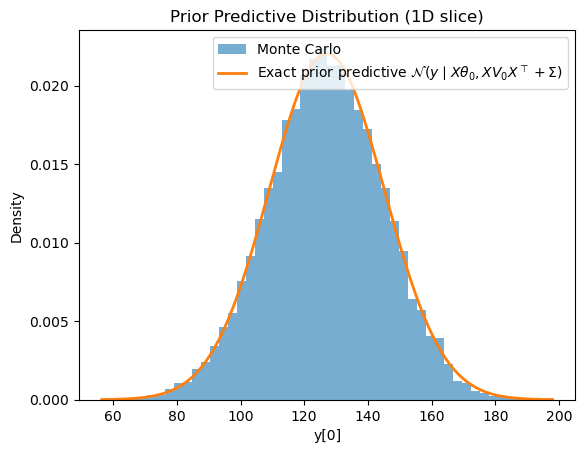

In [4]:
# Monte Carlo Simulation
def prior_predictive_mc_gaussian(theta_0, V0, X, Sigma, M=10000):
    y_samples = []
    
    for _ in range(M):
        # 1. Sample one parameter vector of dimension len(theta_0)
        theta = np.random.multivariate_normal(theta_0, V0)
        
        # 2. Sample len(X @ theta) datapoints at a time
        y = np.random.multivariate_normal(X @ theta, Sigma)
        
        y_samples.append(y)
    
    return np.array(y_samples) # shape (M, n)


np.random.seed(1927)

n = 30 # sample size
X = np.random.uniform(0, 25, (n, 2)) # data

# Prior parameters
theta_0 = np.ones(X.shape[1])*5 # prior mean
tau2 = 1.0
V0 = tau2 * np.eye(X.shape[1]) # prior covariance

# Noise
sigma2 = 0.5 #
Sigma = sigma2 * np.eye(n) # likelihood covariance


# Monte Carlo samples
y_samples = prior_predictive_mc_gaussian(theta_0, V0, X, Sigma, M=20000)


# Exact prior predictive
mean_exact = X @ theta_0
cov_exact = X @ V0 @ X.T + Sigma

# For visualization: pick one dimension (e.g. first entry of y so that now y1 ~ N(Xθ[0],Sigma[0,0])
y1_samples = y_samples[:, 0]

mean_1 = mean_exact[0]
var_1 = cov_exact[0, 0]

x_vals = np.linspace(y1_samples.min(), y1_samples.max(), 200)
pdf_vals = (1 / np.sqrt(2 * np.pi * var_1)) * np.exp(-(x_vals - mean_1)**2 / (2 * var_1))


# Plot
plt.figure()

# Histogram from Monte Carlo
plt.hist(y1_samples, bins=50, density=True, alpha=0.6, label="Monte Carlo")

# Exact Gaussian
plt.plot(x_vals, pdf_vals, linewidth=2, label=r"Exact prior predictive $\mathcal{N}(y\mid X\theta_0,XV_0X^\top + \Sigma)$")

plt.title("Prior Predictive Distribution (1D slice)")
plt.xlabel("y[0]")
plt.ylabel("Density")
plt.legend()
plt.show()

<a class="anchor" id="prior_dist"></a>
## 3. Posterior predictive distribution

**The posterior predictive distribution is the distribution of a new data point after observing data.**

$$
\begin{align*}
p(y_{\text{new}} \mid X,y) &= \int_{\theta \in \Theta} p(y_{\text{new}},\theta \mid X,y)d\theta \hspace{1 mm} \text{ marginalizes out the unknown parameter }\theta \\
p(A,B \mid C) &= p(A \mid B, C)p(B \mid C) \Rightarrow p(y_{\text{new}},\theta \mid X,y)=p(y_{\text{new}}\mid \theta,X,y)p(\theta \mid X,y) \\
p(y_{\text{new}} \mid X,y) &= \int_{\theta \in \Theta} p(y_{\text{new}} \mid \theta,X,y)p(\theta \mid X,y)d\theta \\ 
&y_{\text{new}} \perp\!\!\!\perp y | \theta \Rightarrow p(y_{\text{new}} \mid \theta,X,y) = p(y_{\text{new}} \mid \theta,X)\\
&= \int_{\theta \in \Theta} \underbrace{p(y_{\text{new}} \mid X, \theta)}_{\text{Likelihood}} \underbrace{p(\theta \mid X,y)}_{\text{Posterior}}d\theta \\
&= \int_{\theta \in \mathbb{R}^m} \mathcal{N}(y_{\text{new}}\mid X_{\text{new}}\theta,\Sigma) \mathcal{N}(\theta \mid \theta_n,V_n) d\theta \hspace{1mm} \mid \hspace{1mm} X \in \mathbb{R}^{n \times m} \\
&= \mathcal{N}(y_{\text{new}}\mid X_{\text{new}}\theta_n,X_{\text{new}}V_nX_{\text{new}}^\top + \Sigma) \hspace{1mm} \mid \hspace{1mm}  X_{\text{new}}V_nX_{\text{new}}^\top \text{ is (posterior) parameter uncertainty and } \Sigma \text{ is data noise} 
\end{align*}
$$


### Intuition

1. Observe data $X,y$.
2. Compute posterior $p(\theta \mid X,y)$
3. Sample a parameter from posterior ($\theta \sim \theta \mid X,y$)
4. Generate new data $y_{\text{new}}$ using the parameter
5. Repeat this many times.
4. Look at the distribution of the generated new data $y_{\text{new}}$. That distribution is the posterior predictive distribution.

**Monte Carlo simulation of the Posterior Predcitive Distribution**
1. Sample a parameter vector $\theta \sim \mathcal{N}(\theta_n,V_n)$
2. Generate new data using $X_{\text{new}}$ from $y_{\text{new}} \mid X, \theta \sim \mathcal{N}(X_{\text{new}}\theta,\Sigma)$
3. Repeat $M$ times
4. As $M \rightarrow \infty$ the empirical distribution of the generated $y_{\text{new}}$ converges to $\mathcal{N}(y_{\text{new}}\mid X_{\text{new}}\theta_n,X_{\text{new}}V_nX_{\text{new}}^\top + \Sigma)$




**Relation to the posterior predictive distribution**
| Predictive type          | Formula                                       | When used          |
| ------------------------ | --------------------------------------------- | ------------------ |
| **Prior predictive $p(y)$**      | $ \int p(y\mid\theta)p(\theta)d\theta$      | before seeing data |
| **Posterior predictive $p(y_{\text{new}} \mid X,y)$** | $\int p(y_{\text{new}}\mid X,\theta)p(\theta \mid X,y)d\theta$ | after seeing data  |


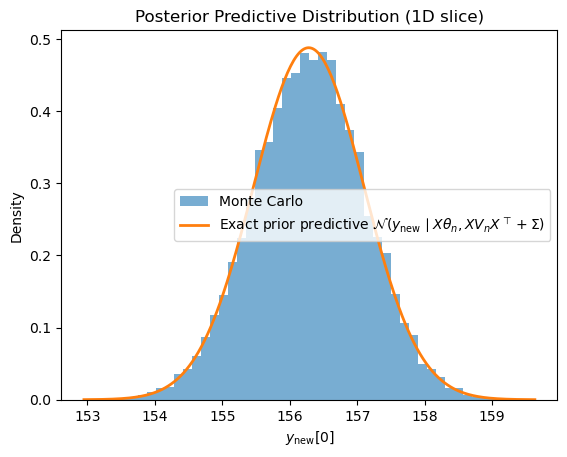

In [5]:
# Monte Carlo Simulation
def posterior_predictive_mc_gaussian(theta_n, Vn, X_new, Sigma, M=10000):
    y_samples = []
    
    for _ in range(M):
        # 1. Sample one parameter vector of dimension len(theta_0)
        theta = np.random.multivariate_normal(theta_n, Vn)
        
        # 2. Sample len(X @ theta) datapoints at a time
        y = np.random.multivariate_normal(X_new @ theta, Sigma)
        
        y_samples.append(y)
    
    return np.array(y_samples) # shape (M, n)


np.random.seed(2001) # for reproducibility

# Data
n = 20
X = np.random.randint(0,25,(n,3))
X = np.c_[np.ones(n),X] # 2 features with intercept -> 3 parameters
true_theta = np.random.uniform(1,5,X.shape[1])
sigma2 = 0.5
error = np.random.normal(0,sigma2,n)
y = X @ true_theta + error

# Likelihood parameters
Sigma = sigma2 * np.eye(n) # likelihood covariance

# Prior parameters
tau2 = 1.4
V0 = tau2 * np.eye(X.shape[1]) # prior covariance
theta_0 = np.zeros(X.shape[1]) # prior mean

# Posterior parameters
Vn = np.linalg.inv(X.T @ np.linalg.inv(Sigma) @ X + np.linalg.inv(V0)) # posterior covariance
theta_n = Vn @ (np.linalg.inv(V0) @ theta_0  + X.T @ np.linalg.inv(Sigma) @ y)

X_new = np.random.randint(0,25,(n,3))
X_new = np.c_[np.ones(n),X_new]

y_samples = posterior_predictive_mc_gaussian(theta_n, Vn, X_new, Sigma, M=20000)

# Exact posterior predictive
mean_exact = X_new @ theta_n
cov_exact = X_new @ Vn @ X_new.T + Sigma

# Take first component of y_new
y1_samples = y_samples[:, 0]

# Exact marginal for y_new[0]
mean_1 = mean_exact[0]
var_1 = cov_exact[0, 0]

x_vals = np.linspace(y1_samples.min(), y1_samples.max(), 300)
pdf_vals = norm.pdf(x_vals, loc=mean_1, scale=np.sqrt(var_1))

# Plot
plt.figure()

# Monte Carlo histogram
plt.hist(y1_samples, bins=50, density=True, alpha=0.6, label="Monte Carlo")

# Exact posterior predictive
plt.plot(x_vals, pdf_vals, linewidth=2, label=r"Exact prior predictive $\mathcal{N}(y_{\text{new}}\mid X\theta_n,XV_nX^\top + \Sigma)$")

plt.title("Posterior Predictive Distribution (1D slice)")
plt.xlabel(r"$y_{\text{new}}[0]$")
plt.ylabel("Density")
plt.legend()

plt.show()

Posterior mean (ridge): [1.07972176 1.96045946]


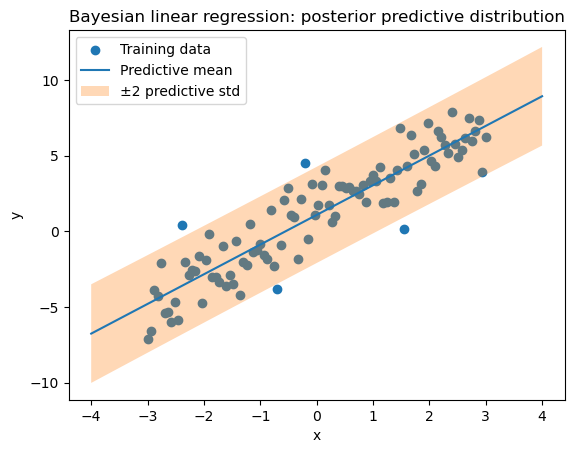

In [14]:
# Generate training data
np.random.seed(2216)

n = 100 # sample size
x = np.linspace(-3, 3, n)
X = np.column_stack([np.ones(n), x]) # intercept + slope

w_true = np.array([1.0, 2.0])
sigma2 = 2.5 # noise variance
tau2 = 1.0 # prior variance

y = X @ w_true + np.sqrt(sigma2) * np.random.randn(n) # target


# Bayesian linear regression (posterior)
Sigma = sigma2 * np.eye(n) # noise covariance
V0 = tau2 * np.eye(X.shape[1])  # prior covariance
theta_0 = np.zeros(X.shape[1]) # prior mean

Vn = np.linalg.inv(X.T @ np.linalg.inv(Sigma) @ X + np.linalg.inv(V0)) # posterior covariance
theta_n = Vn @ (X.T @ np.linalg.inv(Sigma) @ y) # posterior mean

print("Posterior mean (ridge):", theta_n)


# Posterior predictive distribution
x_star = np.linspace(-4, 4, 200)
X_star = np.column_stack([np.ones(len(x_star)), x_star]) # X_star has shape (2,200)

y_mean = X_star @ theta_n # Posterior predictive mean

# Posterior predictive variance: sigma^2 + x^T Vn x
y_var = np.array([
    sigma2 + x_i @ Vn @ x_i
    for x_i in X_star # x_i = (1,x)
])

y_std = np.sqrt(y_var)


# Plot posterior predictive distribution
plt.figure()
plt.scatter(x, y, label="Training data")
plt.plot(x_star, y_mean, label="Predictive mean")
plt.fill_between(
    x_star,
    y_mean - 2 * y_std,
    y_mean + 2 * y_std,
    alpha=0.3,
    label="±2 predictive std"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bayesian linear regression: posterior predictive distribution")
plt.legend()
plt.show()

<a class="anchor" id="library"></a>
## 4. Bayesian linear Regression with libraries

```python
# 1. Bayesian Linear Regression — scikit-learn (BayesianRidge)
from sklearn.linear_model import BayesianRidge

model1 = BayesianRidge(
    n_iter=300, # number of iterations
    tol=1e-3, # convergence tolerance
    alpha_1=1e-6, # hyperprior for noise precision (Gamma prior)
    alpha_2=1e-6,
    lambda_1=1e-6, # hyperprior for weights precision
    lambda_2=1e-6,
    fit_intercept=True, # estimate intercept
    compute_score=False # store log marginal likelihood
)

model1.fit(X, y) # fit Bayesian linear model

model1.coef_ # posterior mean of coefficients
model1.intercept_ # posterior mean of intercept
model1.predict(X) # predictions (mean)
model1.predict(X, return_std=True)  # mean + predictive std
model1.sigma_ # covariance matrix of coefficients
model1.alpha_ # estimated noise precision
model1.lambda_ # estimated weights precision


# 2. Bayesian Linear Regression — PyMC (fully flexible, probabilistic)
import pymc as pm
import numpy as np

with pm.Model() as model2:

    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=10) # intercept
    beta = pm.Normal("beta", mu=0, sigma=10, shape=X.shape[1]) # coefficients
    sigma = pm.HalfNormal("sigma", sigma=1) # noise std

    # Expected value
    mu = alpha + pm.math.dot(X, beta)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Inference (sampling from posterior)
    trace = pm.sample(
        draws=1000, # posterior samples
        tune=1000, # burn-in
        target_accept=0.9,
        random_seed=None
    )

# Posterior summaries
pm.summary(trace)

# Posterior means
alpha_mean = trace.posterior["alpha"].mean().item()
beta_mean = trace.posterior["beta"].mean(axis=(0,1)).values

# Predictions (posterior predictive)
with model2:
    posterior_pred = pm.sample_posterior_predictive(trace)

y_pred = posterior_pred["y_obs"] # samples of predictions


# 3. Bayesian Linear Regression — Bambi (R-style formula interface)
import bambi as bmb
import pandas as pd

# If X is numpy, convert to DataFrame
df = pd.DataFrame(X, columns=[f"x{i}" for i in range(X.shape[1])])
df["y"] = y

# Define model using formula
model3 = bmb.Model(
    "y ~ " + " + ".join(df.columns[:-1]), # e.g. "y ~ x0 + x1 + ..."
    df
)

# Fit model (Bayesian inference via PyMC backend)
results = model3.fit(
    draws=1000,
    tune=1000,
    target_accept=0.9
)

# Posterior summary
print(results.summary())

# Posterior predictive
y_pred = model3.predict(results)

# Access posterior
results.posterior # xarray dataset with samples
```

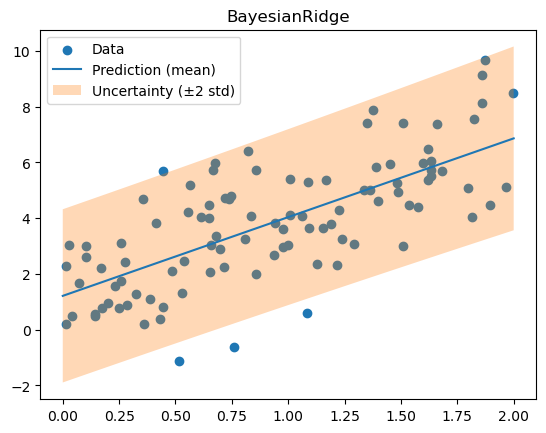

Intercept: 1.2148730123766347
Coefficient: [2.82516324]
Noise precision (alpha): 0.4143362303569414
Weight precision (lambda): 0.1241073588542898


In [6]:
# --- Generate synthetic data ---
np.random.seed(2158)
X = 2 * np.random.rand(100, 1) # data matrix of shape (100,1)
true_coef = 3.0
true_intercept = 1.0

y = true_intercept + true_coef * X.squeeze() + np.random.randn(100) * 1.5

# Fit model
model = BayesianRidge()
model.fit(X, y)

# Predictions
X_test = np.linspace(0, 2, 100).reshape(-1, 1)
y_mean, y_std = model.predict(X_test, return_std=True) # y_mean is mean of posterior predictive distribution
# y_std is square root of posterior predictive distribution variance for each observation instead of full matrix form

# Plot 
plt.scatter(X, y, label="Data")
plt.plot(X_test, y_mean, label="Prediction (mean)")
plt.fill_between(
    X_test.squeeze(),
    y_mean - 2 * y_std,
    y_mean + 2 * y_std,
    alpha=0.3,
    label="Uncertainty (±2 std)"
)
plt.legend()
plt.title("BayesianRidge")
plt.show()


print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)
print("Noise precision (alpha):", model.alpha_)
print("Weight precision (lambda):", model.lambda_)